# Franchise exploration — final figures

Final, poster-ready versions. Shared blue theme, red accent line for means / trend lines.

Figures produced:
1. Rating vs movie # (mean line in red)
2. Revenue vs movie # (mean line in red)
3. Feature importance — what predicts the next movie's rating
4. Rating vs movie # split by top genres
5. Spread of ratings across the franchise — does it stabilize or widen?
6. Time-gap vs rating change — dot plot with trend line
7. Top 50 franchises — revenue vs rating bubble chart

In [55]:
import sys, os, ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("Predictor")
from data_loader import load_tmdb_data
from features import build_features
from model import train_model

TMDB_DIR = "tmdb-movie-metadata"
OUT_DIR = "outputs_done"
os.makedirs(OUT_DIR, exist_ok=True)

THEME = {
    "primary":   "#2c5985",
    "secondary": "#5b9bd5",
    "light":     "#cfe1f2",
    "accent":    "#c92a2a",
    "muted":     "#9aa3ad",
    "text":      "#1f2a36",
}

# distinct palette for genre lines (tab10 — same as the earlier draft)
GENRE_PALETTE = list(plt.cm.tab10.colors)

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (10, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.titlepad": 14,
    "axes.labelsize": 11,
    "axes.edgecolor": THEME["text"],
    "axes.labelcolor": THEME["text"],
    "text.color":  THEME["text"],
    "xtick.color": THEME["text"],
    "ytick.color": THEME["text"],
    "grid.alpha":  0.3,
    "grid.color":  "#dde3ea",
    "font.family": "sans-serif",
})

# shared axis labels — keeps the poster consistent
X_SEQ = "Movie # in franchise"
Y_RATING = "TMDB rating"

MAX_SEQ = 8
MIN_PER_POS = 5

## Load & prep

In [56]:
df = load_tmdb_data(TMDB_DIR)

def parse_genres(x):
    try:
        return [g["name"] for g in ast.literal_eval(x)]
    except Exception:
        return []

raw = pd.read_csv(os.path.join(TMDB_DIR, "movies_metadata.csv"), low_memory=False)
raw["id"] = pd.to_numeric(raw["id"], errors="coerce")
raw["genre_list"] = raw["genres"].apply(parse_genres)
df["id"] = pd.to_numeric(df["id"], errors="coerce")
df = df.merge(raw[["id", "genre_list"]], on="id", how="left")
df["primary_genre"] = df["genre_list"].apply(lambda xs: xs[0] if isinstance(xs, list) and xs else None)

sizes = df.groupby("franchise_id").size()
df = df[df["franchise_id"].isin(sizes[sizes >= 3].index)].copy()
df = df.sort_values(["franchise_id", "releaseYear"])
df["seq"] = df.groupby("franchise_id").cumcount() + 1

print("Movies:", len(df), "| Franchises:", df["franchise_id"].nunique())

Movies: 502 | Franchises: 120


## 1 — Rating vs movie # in franchise

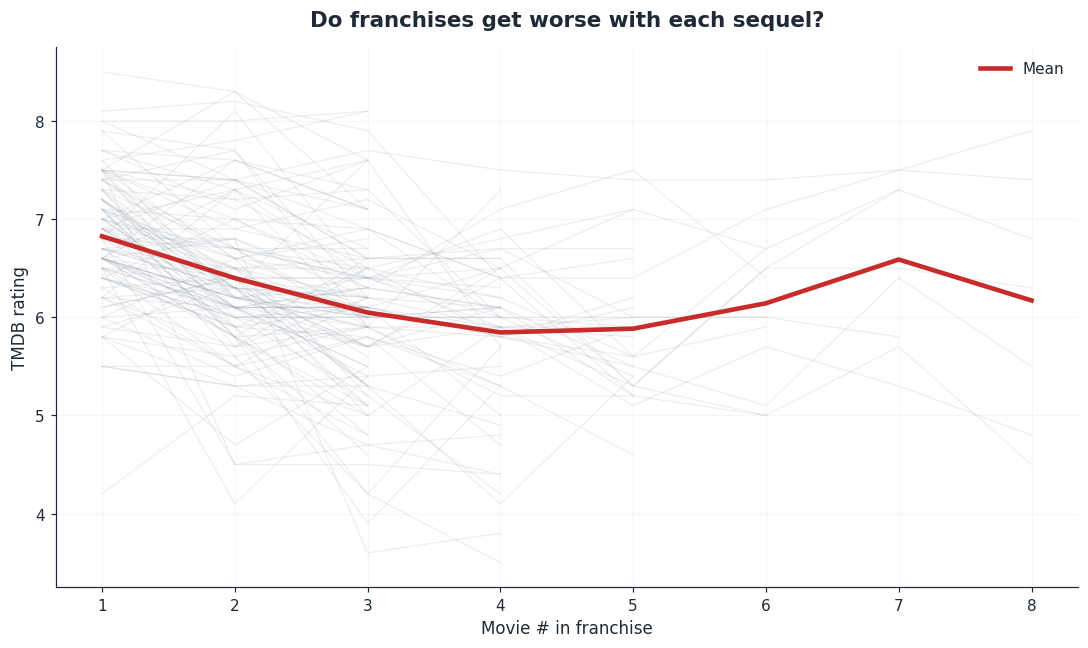

In [57]:
fig, ax = plt.subplots()

for fid, g in df.groupby("franchise_id"):
    g = g[g["seq"] <= MAX_SEQ]
    ax.plot(g["seq"], g["imdbRating"], color=THEME["muted"], alpha=0.18, linewidth=0.8)

agg = (df[df["seq"] <= MAX_SEQ]
       .groupby("seq")["imdbRating"]
       .agg(["mean", "count"]))
agg = agg[agg["count"] >= MIN_PER_POS]
ax.plot(agg.index, agg["mean"], color=THEME["accent"], linewidth=3, label="Mean")

ax.set_xlabel(X_SEQ)
ax.set_ylabel(Y_RATING)
ax.set_title("Do franchises get worse with each sequel?")
ax.set_xticks(range(1, MAX_SEQ + 1))
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/franchise_rating_by_seq.png", dpi=200, bbox_inches="tight")
plt.show()

## 2 — Revenue vs movie # in franchise

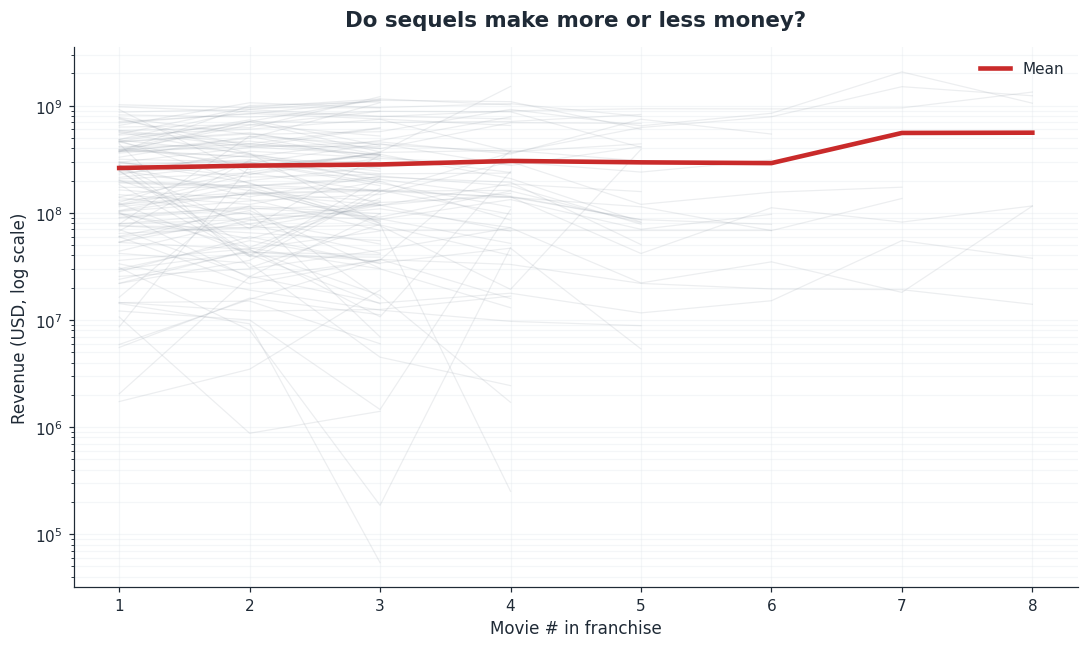

In [58]:
fig, ax = plt.subplots()

for fid, g in df.groupby("franchise_id"):
    g = g[(g["seq"] <= MAX_SEQ) & (g["revenue"] > 0)]
    ax.plot(g["seq"], g["revenue"], color=THEME["muted"], alpha=0.18, linewidth=0.8)

agg = (df[(df["seq"] <= MAX_SEQ) & (df["revenue"] > 0)]
       .groupby("seq")["revenue"]
       .agg(["mean", "count"]))
agg = agg[agg["count"] >= MIN_PER_POS]
ax.plot(agg.index, agg["mean"], color=THEME["accent"], linewidth=3, label="Mean")

ax.set_yscale("log")
ax.set_xlabel(X_SEQ)
ax.set_ylabel("Revenue (USD, log scale)")
ax.set_title("Do sequels make more or less money?")
ax.set_xticks(range(1, MAX_SEQ + 1))
ax.legend(frameon=False)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/franchise_revenue_by_seq.png", dpi=200, bbox_inches="tight")
plt.show()

## 3 — Feature importance: what predicts the next movie's rating?

Test MAE: 0.468


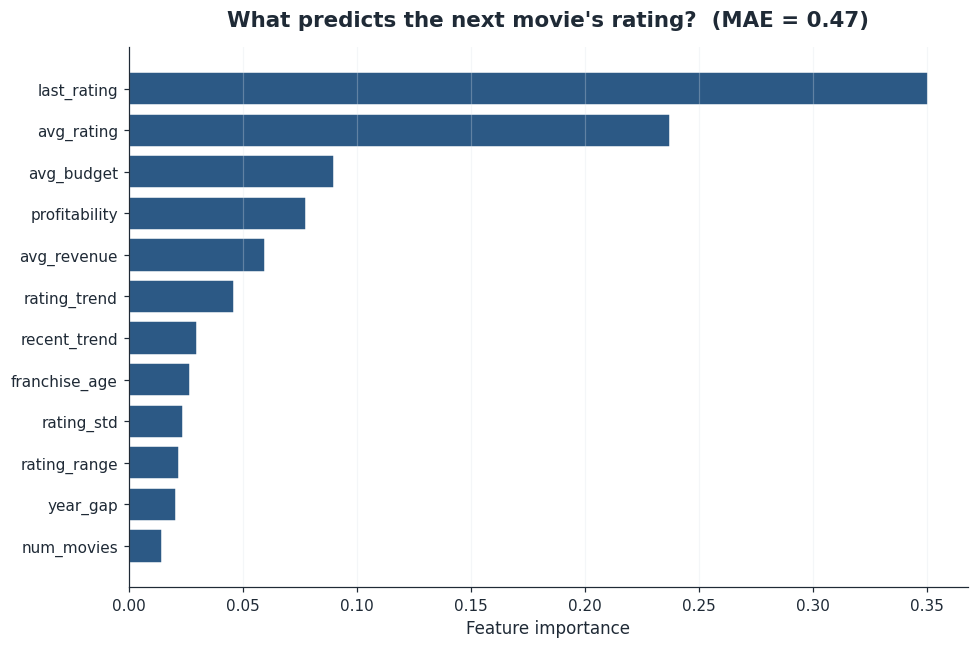

In [59]:
feat_df = build_features(df).dropna()
model, mae = train_model(feat_df)
print(f"Test MAE: {mae:.3f}")

X_cols = [c for c in feat_df.columns if c != "target"]
imp = pd.Series(model.feature_importances_, index=X_cols).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp.index, imp.values, color=THEME["primary"], edgecolor="white")
ax.set_xlabel("Feature importance")
ax.set_title(f"What predicts the next movie's rating?  (MAE = {mae:.2f})")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()

## 4 — Rating trajectory by top genres

Franchises per genre (top 15):
franchise_genre
Action             39
Adventure          23
Comedy             19
Horror             16
Science Fiction     5
Animation           5
Drama               4
Fantasy             4
Crime               1
Family              1
Western             1
Music               1
Thriller            1
Name: count, dtype: int64


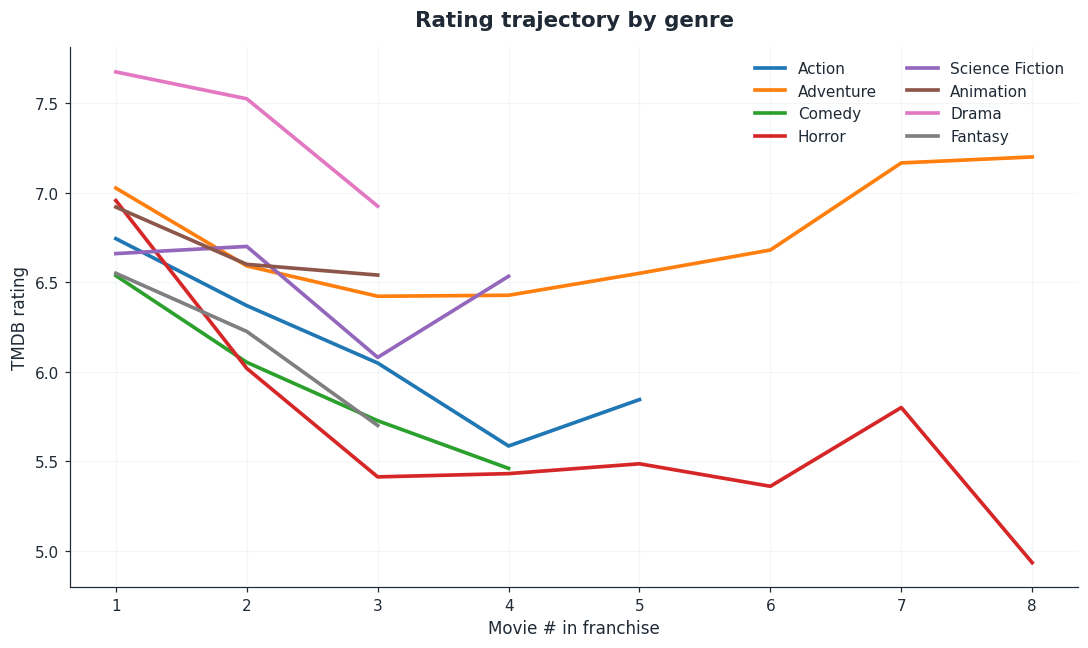

In [60]:
TOP_N_GENRES = 8  # bumped up — show every genre with enough franchises

franchise_genre = (df.dropna(subset=["primary_genre"])
                     .groupby("franchise_id")["primary_genre"]
                     .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else None))
df["franchise_genre"] = df["franchise_id"].map(franchise_genre)

genre_counts = df.drop_duplicates("franchise_id")["franchise_genre"].value_counts()
print("Franchises per genre (top 15):")
print(genre_counts.head(15))
top_genres = genre_counts.head(TOP_N_GENRES).index.tolist()

fig, ax = plt.subplots()
for i, gname in enumerate(top_genres):
    sub = df[(df["franchise_genre"] == gname) & (df["seq"] <= MAX_SEQ)]
    agg = sub.groupby("seq")["imdbRating"].agg(["mean", "count"])
    agg = agg[agg["count"] >= 3]
    ax.plot(agg.index, agg["mean"], color=GENRE_PALETTE[i],
            linewidth=2.4, label=gname)

ax.set_xlabel(X_SEQ)
ax.set_ylabel(Y_RATING)
ax.set_title("Rating trajectory by genre")
ax.set_xticks(range(1, MAX_SEQ + 1))
ax.legend(frameon=False, loc="best", ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/franchise_rating_by_genre.png", dpi=200, bbox_inches="tight")
plt.show()

## 5 — Does the rating spread stabilize or widen?

Boxplot per movie position. Each box = the middle 50% of franchise ratings at that position; whiskers extend to the rest of the distribution. **Taller box = wider spread.** The red line traces the mean rating across positions.

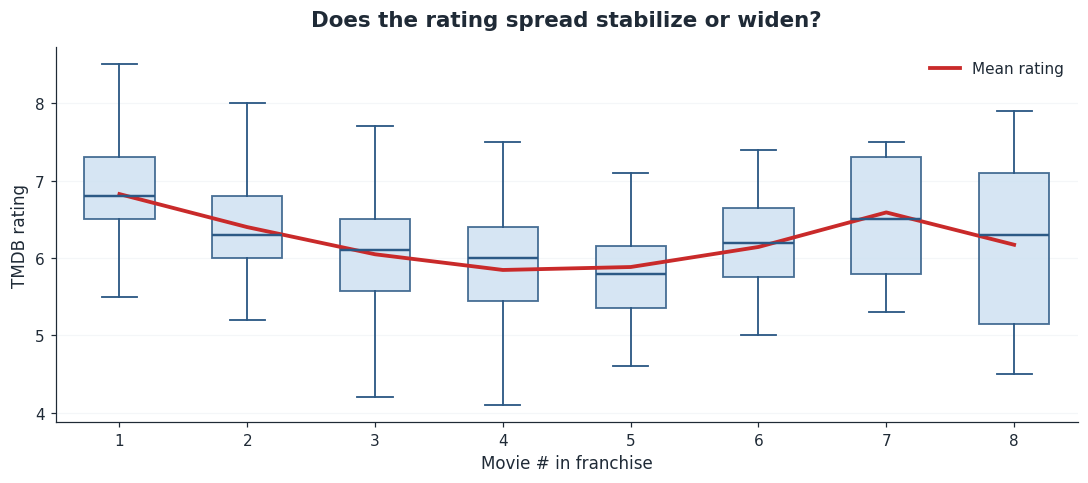

In [61]:
sub = df[df["seq"] <= MAX_SEQ]
positions = sorted(sub["seq"].unique())
data = [sub.loc[sub["seq"] == s, "imdbRating"].values for s in positions]

fig, ax = plt.subplots(figsize=(10, 4.5))

bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.55,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color=THEME["primary"], linewidth=1.6),
    whiskerprops=dict(color=THEME["primary"], linewidth=1.2),
    capprops=dict(color=THEME["primary"], linewidth=1.2),
    boxprops=dict(edgecolor=THEME["primary"], linewidth=1.2),
)
for patch in bp["boxes"]:
    patch.set_facecolor(THEME["light"])
    patch.set_alpha(0.85)

# red mean line on top
means = [arr.mean() for arr in data]
ax.plot(positions, means, color=THEME["accent"], linewidth=2.5, label="Mean rating")

ax.set_xlabel(X_SEQ)
ax.set_ylabel(Y_RATING)
ax.set_title("Does the rating spread stabilize or widen?")
ax.set_xticks(positions)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/franchise_rating_spread.png", dpi=200, bbox_inches="tight")
plt.show()

## 6 — Time gap vs rating change

One dot per sequel: years since the previous movie (x) vs change in rating (y). Linear trend line in red.

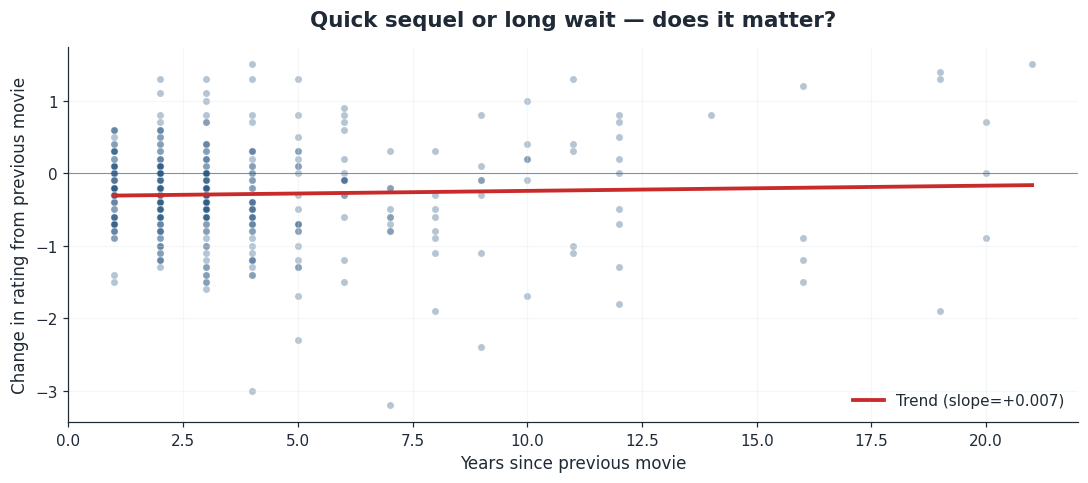

In [62]:
rows = []
for fid, g in df.groupby("franchise_id"):
    g = g.sort_values("releaseYear").reset_index(drop=True)
    for i in range(1, len(g)):
        gap = g.loc[i, "releaseYear"] - g.loc[i-1, "releaseYear"]
        delta = g.loc[i, "imdbRating"] - g.loc[i-1, "imdbRating"]
        if 0 < gap <= 25:
            rows.append({"gap": gap, "delta": delta})

gap_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.scatter(gap_df["gap"], gap_df["delta"], alpha=0.35, s=22,
           color=THEME["primary"], edgecolor="white", linewidth=0.4)

slope, intercept = np.polyfit(gap_df["gap"], gap_df["delta"], 1)
xs = np.linspace(gap_df["gap"].min(), gap_df["gap"].max(), 100)
ax.plot(xs, slope * xs + intercept, color=THEME["accent"], linewidth=2.5,
        label=f"Trend (slope={slope:+.3f})")

ax.axhline(0, color=THEME["text"], linewidth=0.7, alpha=0.5)
ax.set_xlabel("Years since previous movie")
ax.set_ylabel("Change in rating from previous movie")
ax.set_title("Quick sequel or long wait — does it matter?")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/franchise_time_gap.png", dpi=200, bbox_inches="tight")
plt.show()

## 7 — Top 50 franchises: revenue vs rating

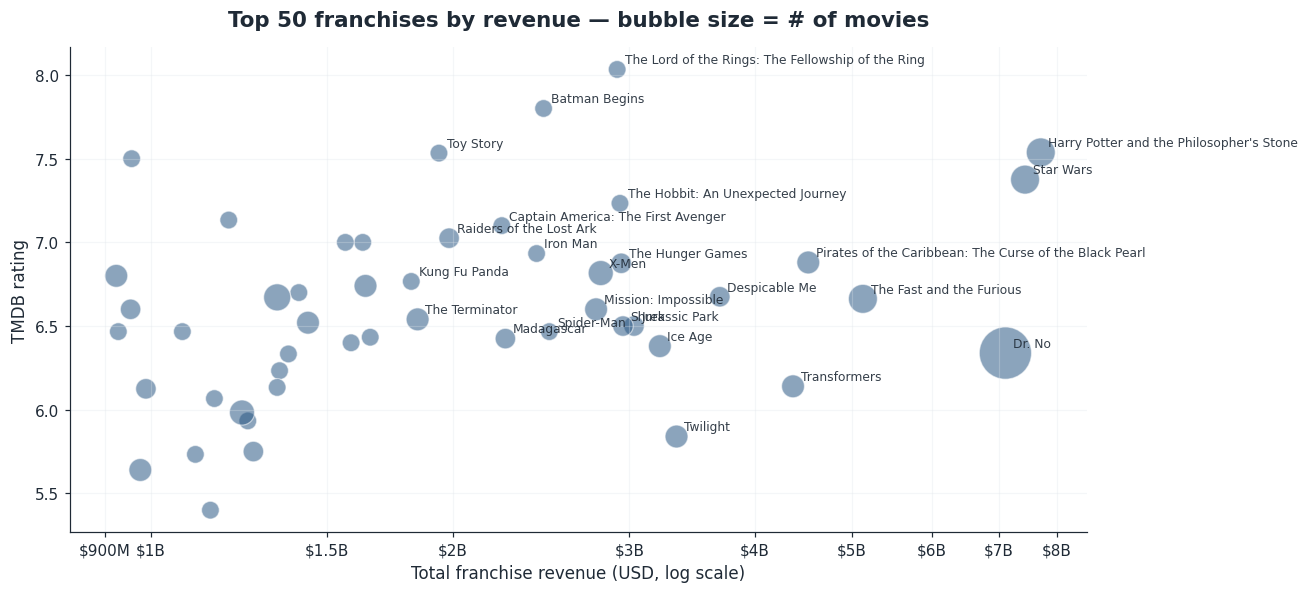

In [63]:
from matplotlib.ticker import LogLocator, FuncFormatter, NullFormatter

agg = (df.groupby("franchise_id")
         .agg(rating=("imdbRating", "mean"),
              revenue=("revenue", "sum"),
              n=("id", "size"),
              name=("originalTitle", "first"))
         .reset_index())
agg = agg[agg["revenue"] > 0]

TOP_N = 50
LABEL_N = 25
top = agg.nlargest(TOP_N, "revenue").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.scatter(top["revenue"], top["rating"], s=top["n"] * 45, alpha=0.55,
           color=THEME["primary"], edgecolor="white", linewidth=0.8)

ax.set_xscale("log")

def fmt_money(x, _):
    if x >= 1e9:
        return f"${x/1e9:g}B"
    if x >= 1e6:
        return f"${x/1e6:g}M"
    return f"${x:,.0f}"

# all ticks promoted to major so they share one consistent style
tick_subs = (1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0)
ax.xaxis.set_major_locator(LogLocator(base=10, subs=tick_subs, numticks=40))
ax.xaxis.set_major_formatter(FuncFormatter(fmt_money))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=()))
ax.xaxis.set_minor_formatter(NullFormatter())

for _, r in top.head(LABEL_N).iterrows():
    ax.annotate(r["name"], (r["revenue"], r["rating"]),
                fontsize=8, alpha=0.9, color=THEME["text"],
                xytext=(5, 4), textcoords="offset points")

ax.set_xlabel("Total franchise revenue (USD, log scale)")
ax.set_ylabel(Y_RATING)
ax.set_title(f"Top {TOP_N} franchises by revenue — bubble size = # of movies")
ax.grid(alpha=0.3, which="major")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/top_franchises.png", dpi=200, bbox_inches="tight")
plt.show()